# Open the files

We generally need two (edges and node attributes).

In [117]:
fileLink_edges='https://github.com/MagallanesAtAlacip/datafiles/raw/main/edges.csv'
fileLink_attributes='https://github.com/MagallanesAtAlacip/datafiles/raw/main/nodeattributes.csv'

import pandas as pd

edges=pd.read_csv(fileLink_edges)
attributes=pd.read_csv(fileLink_attributes)

In [118]:
edges

,source,target,traffic
0,rachelerman,mattmcilwain,35
1,rachelerman,DaveParkerSEA,5
2,rachelerman,toddbishop,7
3,rachelerman,ashannstew,4
4,rachelerman,LeslieFeinzaig,7
...,...,...,...
388,tarah,nhuntwalker,5
389,Jenerationy,PeterHamilton,6
390,Kristen_Hammy,mcolacurcio,8
391,nhuntwalker,JenMsft,9


In [119]:
attributes

,name,male,followers
0,rachelerman,0,7139
1,mattmcilwain,1,2804
2,DaveParkerSEA,1,3328
3,toddbishop,1,24500
4,ashannstew,0,3382
5,LeslieFeinzaig,0,15900
6,akipman,1,29500
7,matt_oppy,1,4847
8,gilbert,1,25800
9,juliesandler,0,7031


# Creating the Network from DataFrames

Use the previous dataframes to create the network:

* From the edges:

In [120]:
import networkx as nx # package needed

EliteNet =nx.from_pandas_edgelist(edges, edge_attr="traffic") # we have this edge attribute (3rd column)


We have:

In [121]:

print(EliteNet)

Graph with 46 nodes and 393 edges


A view of Edges:

In [122]:
EliteNet.edges(data=True)

EdgeDataView([('rachelerman', 'mattmcilwain', {'traffic': 35}), ('rachelerman', 'DaveParkerSEA', {'traffic': 5}), ('rachelerman', 'toddbishop', {'traffic': 7}), ('rachelerman', 'ashannstew', {'traffic': 4}), ('rachelerman', 'LeslieFeinzaig', {'traffic': 7}), ('rachelerman', 'akipman', {'traffic': 7}), ('rachelerman', 'matt_oppy', {'traffic': 4}), ('rachelerman', 'gilbert', {'traffic': 8}), ('rachelerman', 'juliesandler', {'traffic': 7}), ('rachelerman', 'BradSmi', {'traffic': 5}), ('rachelerman', 'crashdev', {'traffic': 6}), ('rachelerman', 'ShaunaCausey', {'traffic': 7}), ('rachelerman', 'john_gabbert', {'traffic': 8}), ('rachelerman', 'moniguzman', {'traffic': 4}), ('rachelerman', 'mattmday', {'traffic': 8}), ('rachelerman', 'Rich_Barton', {'traffic': 6}), ('rachelerman', 'daryn', {'traffic': 40}), ('rachelerman', 'lovelletters', {'traffic': 7}), ('rachelerman', 'etzioni', {'traffic': 9}), ('rachelerman', 'MissDestructo', {'traffic': 4}), ('rachelerman', 'heatherredman', {'traffic': 

## Adding Attributes to Network Nodes

Attributes are added using dictionaries _{node_name:attribute_value}_:

In [123]:
# currently
EliteNet.nodes(data=True)

NodeDataView({'rachelerman': {}, 'mattmcilwain': {}, 'DaveParkerSEA': {}, 'toddbishop': {}, 'ashannstew': {}, 'LeslieFeinzaig': {}, 'akipman': {}, 'matt_oppy': {}, 'gilbert': {}, 'juliesandler': {}, 'BradSmi': {}, 'crashdev': {}, 'ShaunaCausey': {}, 'john_gabbert': {}, 'moniguzman': {}, 'mattmday': {}, 'Rich_Barton': {}, 'daryn': {}, 'lovelletters': {}, 'etzioni': {}, 'MissDestructo': {}, 'heatherredman': {}, 'danshapiro': {}, 'medinism': {}, 'KieranSnyder': {}, 'hadip': {}, 'RajSinghSeattle': {}, 'Ryanintheus': {}, 'sonalpmane': {}, 'marybethlambert': {}, 'Jenerationy': {}, 'funcOfJoe': {}, 'kirbywinfield': {}, 'Kristen_Hammy': {}, 'stevesi': {}, 'SoGulley': {}, '2morrowknight': {}, 'jinman': {}, 'tarah': {}, 'lanctot': {}, 'nhuntwalker': {}, 'eugenio_pace': {}, 'JenMsft': {}, 'PeterHamilton': {}, 'sarahstood': {}, 'mcolacurcio': {}})

In [124]:
# create dictionaries

dictAttribute_male=dict(zip(attributes.name,attributes.male))
dictAttribute_followers=dict(zip(attributes.name,attributes.followers))

In [125]:
# this is the structure:
dictAttribute_male

{'rachelerman': 0,
 'mattmcilwain': 1,
 'DaveParkerSEA': 1,
 'toddbishop': 1,
 'ashannstew': 0,
 'LeslieFeinzaig': 0,
 'akipman': 1,
 'matt_oppy': 1,
 'gilbert': 1,
 'juliesandler': 0,
 'BradSmi': 1,
 'crashdev': 0,
 'ShaunaCausey': 0,
 'john_gabbert': 1,
 'moniguzman': 0,
 'mattmday': 1,
 'Rich_Barton': 1,
 'daryn': 1,
 'lovelletters': 0,
 'etzioni': 1,
 'MissDestructo': 0,
 'heatherredman': 0,
 'danshapiro': 1,
 'medinism': 1,
 'KieranSnyder': 0,
 'hadip': 1,
 'RajSinghSeattle': 1,
 'funcOfJoe': 1,
 'kirbywinfield': 1,
 'stevesi': 1,
 'Ryanintheus': 1,
 'sonalpmane': 0,
 'SoGulley': 0,
 '2morrowknight': 1,
 'jinman': 1,
 'tarah': 0,
 'Jenerationy': 0,
 'lanctot': 1,
 'Kristen_Hammy': 0,
 'nhuntwalker': 1,
 'eugenio_pace': 1,
 'JenMsft': 0,
 'PeterHamilton': 1,
 'sarahstood': 0,
 'mcolacurcio': 0,
 'marybethlambert': 0}

In [126]:
# set attribute with the dictionaries

nx.set_node_attributes(EliteNet, dictAttribute_male,'male')
nx.set_node_attributes(EliteNet, dictAttribute_followers,'followers')

In [127]:
## see them
EliteNet.nodes(data=True)

NodeDataView({'rachelerman': {'male': 0, 'followers': 7139}, 'mattmcilwain': {'male': 1, 'followers': 2804}, 'DaveParkerSEA': {'male': 1, 'followers': 3328}, 'toddbishop': {'male': 1, 'followers': 24500}, 'ashannstew': {'male': 0, 'followers': 3382}, 'LeslieFeinzaig': {'male': 0, 'followers': 15900}, 'akipman': {'male': 1, 'followers': 29500}, 'matt_oppy': {'male': 1, 'followers': 4847}, 'gilbert': {'male': 1, 'followers': 25800}, 'juliesandler': {'male': 0, 'followers': 7031}, 'BradSmi': {'male': 1, 'followers': 96300}, 'crashdev': {'male': 0, 'followers': 8773}, 'ShaunaCausey': {'male': 0, 'followers': 47400}, 'john_gabbert': {'male': 1, 'followers': 2482}, 'moniguzman': {'male': 0, 'followers': 29000}, 'mattmday': {'male': 1, 'followers': 5750}, 'Rich_Barton': {'male': 1, 'followers': 31300}, 'daryn': {'male': 1, 'followers': 2378}, 'lovelletters': {'male': 0, 'followers': 4553}, 'etzioni': {'male': 1, 'followers': 27400}, 'MissDestructo': {'male': 0, 'followers': 41800}, 'heatherre

A simple command `draw()` will plot the graph:

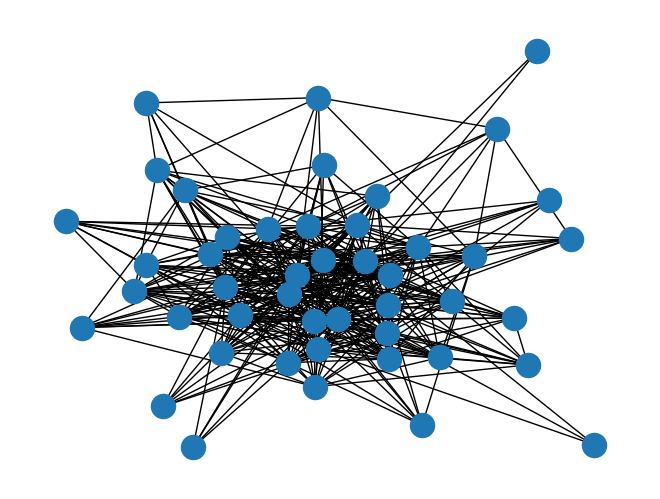

In [128]:
nx.draw(EliteNet)

# Exploration of the network

## Basic metrics



### Connectedness:

A network is  “connected” if there exists a _path_ between any pair of nodes (undirected networks).

In [129]:
nx.is_connected(EliteNet)

True

### Density:

from 0 to 1, where 1 makes it a ‘complete’ network: there is a link between every pair of nodes.

In [130]:
nx.density(EliteNet)

0.37971014492753624

### Diameter:

When two vertices are connected, one can reach the other using multiple egdes. The geodesic is the shorthest path between two connected vertices. Then, the diameter, is the maximum geodesic in a network.

> That is the worst case escenario for a person to reach another is having `diameter-1` intermediaries.

In [131]:
nx.diameter(EliteNet)

3

## Visuals

Visuals are key for complementary analysis. But it is not an easy task.

### Assortativity

Assortativity is a measure to see if nodes are connecting to other nodes similar to themselves. Closer to 1 means higher assortativity, closer to -1 diassortativity; while 0 is no assortativity.
Assortativity can be measured in three complementary ways:

a.  Categorical assortativity: tendency for nodes with other nodes sharing the same category.

In [132]:
nx.attribute_assortativity_coefficient(EliteNet,'male')

0.043102108480546866

> With r ≈ 0.043, gender is effectively irrelevant: same-sex and cross-sex ties are distributed no differently than chance would predict.

`Layouts` help show the complexity of a graph without becoming an analytical tool. If patterns are not shockingly clear, eye bias may interpret visual artifacts when they mean nothing.

Let me prepare a layout to see if we can effectively interpret the close-to-zero value of assortativity for the male attribute:

* Differentiate the node attribute:

We will just color the nodes, and see if we can detect the assortativity (lack of it):

In [133]:
gender_values_forCMAP = [EliteNet.nodes[n]['male'] for n in EliteNet.nodes()]


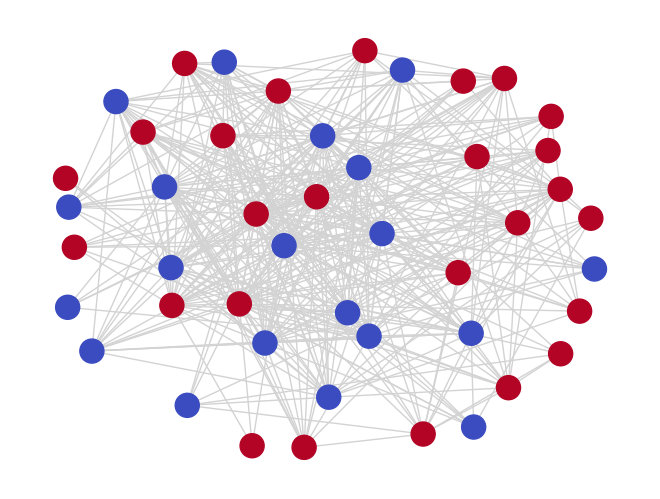

In [134]:
pos = nx.spring_layout(EliteNet, seed=42, k=2.6)

nx.draw(EliteNet, pos,
        node_color=gender_values_forCMAP,
        cmap='coolwarm',
        edge_color='lightgray')



A next step would be to see the edge pattern. Let me split the edges:

In [135]:
# edges between same sex nodes
same_sex = [(u, v) for u, v in EliteNet.edges()
            if EliteNet.nodes[u]['male'] == EliteNet.nodes[v]['male']]

# edges between nodes of different sex
cross_sex = [e for e in EliteNet.edges() if e not in same_sex]

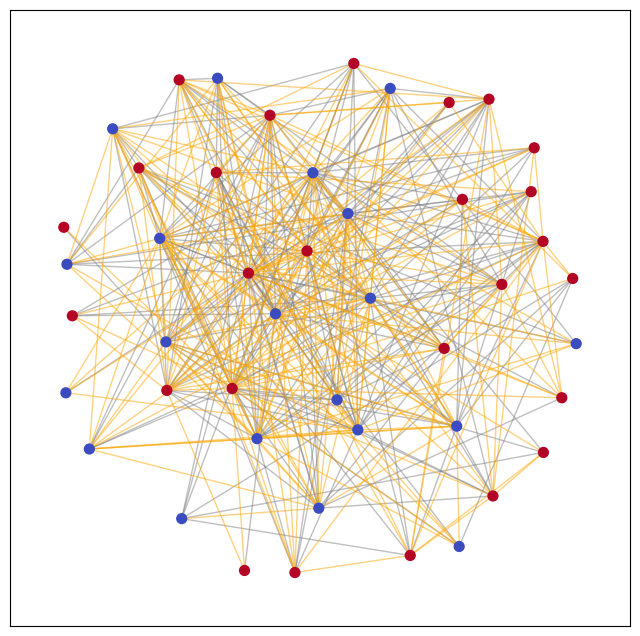

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))


# only Nodes
nx.draw_networkx_nodes(EliteNet, pos,
                       node_color=gender_values_forCMAP, cmap='coolwarm',
                       node_size=50)

# on top, the first group of edges
nx.draw_networkx_edges(EliteNet, pos, edgelist=cross_sex,
                       edge_color='gray', alpha=0.5)

# on top, the other group of edges
nx.draw_networkx_edges(EliteNet, pos, edgelist=same_sex,
                       edge_color='orange', alpha=0.5)

Can you detect if gender homophily exists? Do crimson same-sex edges cluster within color groups, or are they scattered randomly?

Most of the time, visuals require knowing what actual math happened behind the scenes. In this case, assortativity needs simple crosstabulation as the initial input:

In [137]:
mix_mat = nx.attribute_mixing_matrix(EliteNet, 'male')
mix_mat

array([[0.25445293, 0.23918575],
       [0.23918575, 0.26717557]])

`mix_mat` is the normalized mixing matrix M  — a joint probability distribution:
| Cell     | Meaning                                      |
| -------- | -------------------------------------------- |
| `M[0,0]` | Fraction of edges connecting female → female |
| `M[0,1]` | Fraction of edges connecting female → male   |
| `M[1,0]` | Fraction of edges connecting male → female   |
| `M[1,1]` | Fraction of edges connecting male → male     |


As mentioned above, notice Python has normalized the matrix (following the theory for unidirected graphs). Let me show you the non normalized version:

In [138]:
male = nx.get_node_attributes(EliteNet, 'male')
df = pd.DataFrame([(male[u], male[v]) for u, v in EliteNet.edges()])
mix = pd.crosstab(df[0], df[1])

print(mix)

1    0    1
0          
0  100  101
1   87  105


In [139]:
# Symmetrize for undirected graph (matches NetworkX exactly)
mix_sym = (mix + mix.T) / 2
print(mix_sym)

1      0      1
0              
0  100.0   94.0
1   94.0  105.0


In [140]:
# Normalize
M = mix_sym.values / mix_sym.values.sum()
M_df = pd.DataFrame(M, index=mix.index, columns=mix.columns)
M_df

1,0,1
0,,
0,0.254453,0.239186
1,0.239186,0.267176


We can compute assortativity from the table:

In [141]:
import numpy as np

a = M_df.sum(axis=1)
r = (np.trace(M_df) - np.sum(a**2)) / (1 - np.sum(a**2))
print(f"\nManual r:  {r:.6f}")


Manual r:  0.043102


| Line                   | What it does                  | Mathematical meaning                                                    |
| ---------------------- | ----------------------------- | ----------------------------------------------------------------------- |
| `a = M_df.sum(axis=1)` | Row sums of the mixing matrix | $a_i = \sum_j e_{ij}$ — fraction of all edge-ends attached to group $i$ |
| `np.trace(M_df)`       | Sum of diagonal elements      | $\sum_i e_{ii}$ — fraction of same-type edges                           |
| `np.sum(a**2)`         | Sum of squared marginals      | $\sum_i a_i^2$ — what the diagonal would be under independence          |
| `1 - np.sum(a**2)`     | Denominator                   | Normalization factor — maximum possible deviation from independence     |




$$r = \frac{\sum_i e_{ii} - \sum_i a_i^2}{1 - \sum_i a_i^2}$$

A simple plot would explain the lack of assortativity:

<Axes: xlabel='1', ylabel='0'>

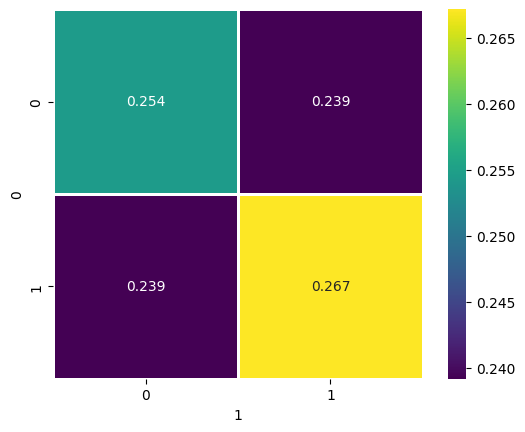

In [142]:
# Plot
import seaborn as sns

sns.heatmap(M_df, annot=True, fmt='.3f', cmap='viridis', square=True, linewidths=1)


Still, the plot above needs some work:

<Axes: xlabel='1', ylabel='0'>

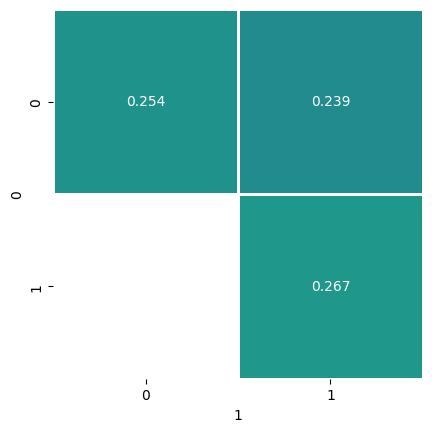

In [143]:

# Mask lower triangle (keep diagonal + upper)
mask = np.tril(np.ones_like(M_df, dtype=bool), k=-1)

sns.heatmap(M_df, mask=mask, annot=True, fmt='.3f', cmap='viridis',
            vmin=0, vmax=0.5, square=True, linewidths=1, cbar=False)

b. Assortativity (numerical):

In [144]:
nx.numeric_assortativity_coefficient(EliteNet,'followers')

-0.04515661740589615

> The result above suggests no diassortativity. Value too close to zero.

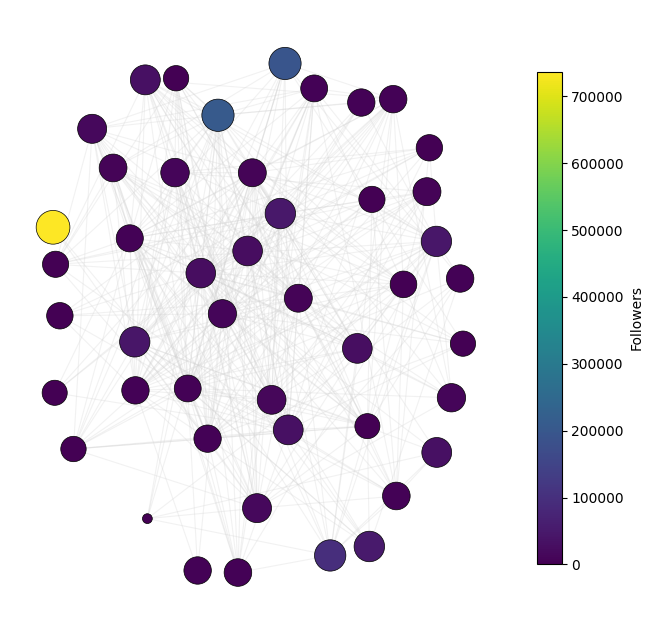

In [145]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

pos = nx.spring_layout(EliteNet, seed=42, k=2.6)

# Followers for color and size
followers = nx.get_node_attributes(EliteNet, 'followers')
follower_values = [followers[n] for n in EliteNet.nodes()]
node_sizes = [50 + np.log1p(followers[n]) * 40 for n in EliteNet.nodes()]

plt.figure(figsize=(8, 8))

# Nodes: color and size by followers
nodes = nx.draw_networkx_nodes(EliteNet, pos,
                                 node_color=follower_values,
                                 cmap='viridis',
                                 node_size=node_sizes,
                                 edgecolors='black',
                                 linewidths=0.5)

# All edges: neutral, faint
nx.draw_networkx_edges(EliteNet, pos,
                         edge_color='lightgray', alpha=0.3, width=0.8)

plt.colorbar(nodes, shrink=0.8, label='Followers')
plt.axis('off')
plt.show()

It is not easy to inform  the lack of assortativity from the plot above. Then, again reflect on what we are representing mathematically.

The question now is: `do popular people tend to connect with popular people?` or `with unpopular ones?`

Let's take a look: at this edge behavior:

In [146]:
# this is how many followers each has:
followers = nx.get_node_attributes(EliteNet, 'followers')
followers

{'rachelerman': 7139,
 'mattmcilwain': 2804,
 'DaveParkerSEA': 3328,
 'toddbishop': 24500,
 'ashannstew': 3382,
 'LeslieFeinzaig': 15900,
 'akipman': 29500,
 'matt_oppy': 4847,
 'gilbert': 25800,
 'juliesandler': 7031,
 'BradSmi': 96300,
 'crashdev': 8773,
 'ShaunaCausey': 47400,
 'john_gabbert': 2482,
 'moniguzman': 29000,
 'mattmday': 5750,
 'Rich_Barton': 31300,
 'daryn': 2378,
 'lovelletters': 4553,
 'etzioni': 27400,
 'MissDestructo': 41800,
 'heatherredman': 3957,
 'danshapiro': 10900,
 'medinism': 2084,
 'KieranSnyder': 15400,
 'hadip': 43300,
 'RajSinghSeattle': 4991,
 'Ryanintheus': 194239,
 'sonalpmane': 1215,
 'marybethlambert': 1010,
 'Jenerationy': 13272,
 'funcOfJoe': 9510,
 'kirbywinfield': 6230,
 'Kristen_Hammy': 1196,
 'stevesi': 206666,
 'SoGulley': 965,
 '2morrowknight': 737130,
 'jinman': 4781,
 'tarah': 48992,
 'lanctot': 5519,
 'nhuntwalker': 5032,
 'eugenio_pace': 4908,
 'JenMsft': 0,
 'PeterHamilton': 7329,
 'sarahstood': 1118,
 'mcolacurcio': 2039}

In [147]:
# given
list(EliteNet.edges())[:5]

[('rachelerman', 'mattmcilwain'),
 ('rachelerman', 'DaveParkerSEA'),
 ('rachelerman', 'toddbishop'),
 ('rachelerman', 'ashannstew'),
 ('rachelerman', 'LeslieFeinzaig')]

In [148]:
followers['rachelerman'], followers['mattmcilwain']

(7139, 2804)

In [149]:
followers['rachelerman'], followers['DaveParkerSEA']

(7139, 3328)

Let's compute a simple correlation:

In [150]:
df_uv_followers = pd.DataFrame([(followers[u], followers[v]) for u, v in EliteNet.edges()],
                  columns=['u_fol', 'v_fol'])

df_uv_followers['u_fol'].corr(df_uv_followers['v_fol'])

np.float64(-0.049076582691269306)

BUT we have a problem.

`df_uv_followers` creates two columns: `u_fol` and `v_fol`. The names imply **direction** — "source followers" and "target followers." But EliteNet is **undirected**. There is no source, no target, no flow from u to v.

The, the  correlation  represents the question: "Does the source's popularity predict the target's popularity?"

**For undirected networks, only symetric questions are possible:**

> "Do two connected nodes tend to have similar follower counts?"


**The symmetric version fixes this:**

In [151]:
pairs = []
for u, v in EliteNet.edges():
    pairs.append((followers[u], followers[v]))  # u → v
    pairs.append((followers[v], followers[u]))  # v → u

df_sym = pd.DataFrame(pairs, columns=['u_fol', 'v_fol'])
df_sym['u_fol'].corr(df_sym['v_fol'])

np.float64(-0.04515661740589616)

And the value expected appears.

Now we can use `df_sym` for the new plot:

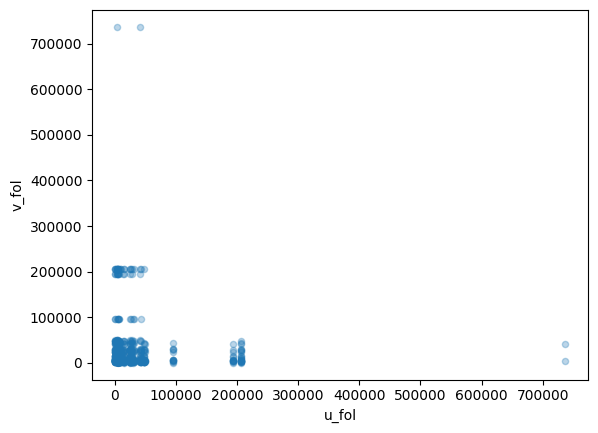

In [152]:
df_sym.plot.scatter(x='u_fol', y='v_fol', alpha=0.3)
plt.show()

Or to highlight the correlation strength:

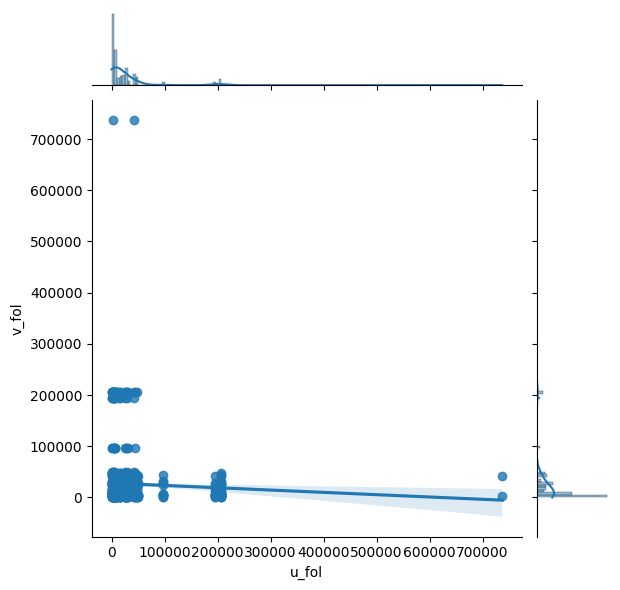

In [153]:
g = sns.jointplot(data=df_sym, x='u_fol', y='v_fol',
                  kind='reg');


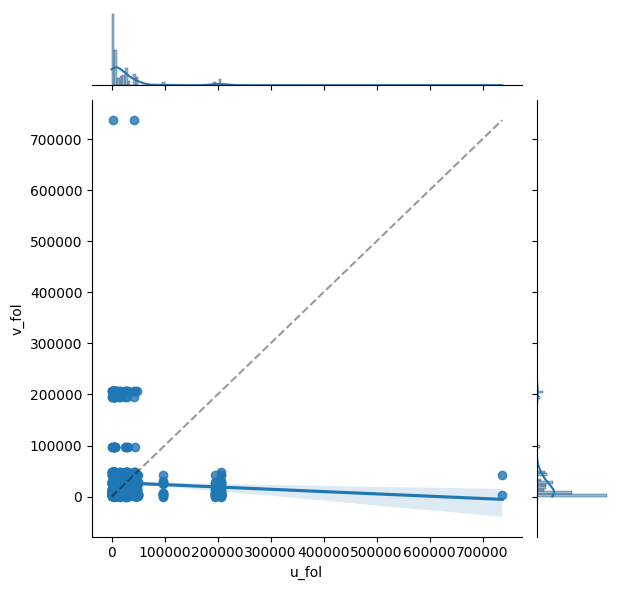

In [154]:
g = sns.jointplot(data=df_sym, x='u_fol', y='v_fol',
                  kind='reg')

max_f = max(df_sym['u_fol'].max(), df_sym['v_fol'].max())

g.ax_joint.plot([0, max_f], [0, max_f], 'k--', alpha=0.4)

plt.show()

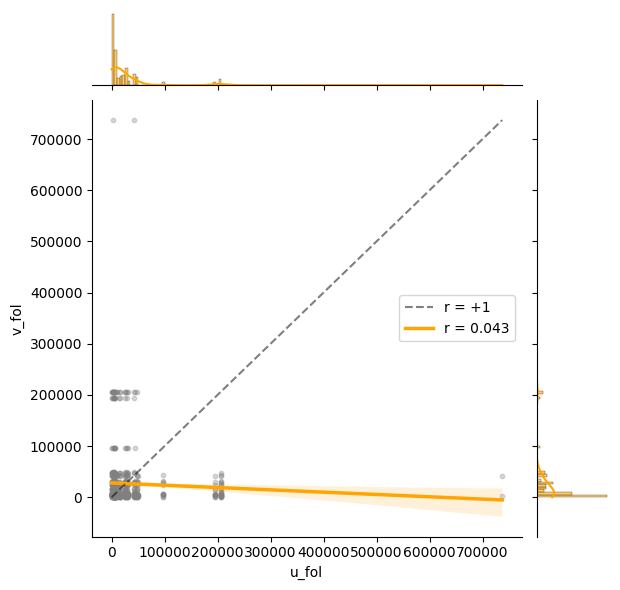

In [155]:
g = sns.jointplot(data=df_sym, x='u_fol', y='v_fol',
                  kind='reg',
                  joint_kws={'scatter_kws': {'alpha': 0.3, 'color': 'grey', 's': 10},
                             'line_kws': {'color': 'orange', 'linewidth': 2.5}},
                  marginal_kws={'color': 'orange', 'alpha': 0.6})

max_f = max(df_sym['u_fol'].max(), df_sym['v_fol'].max())

g.ax_joint.plot([0, max_f], [0, max_f], 'k--', alpha=0.5, linewidth=1.5, label='r = +1')


g.ax_joint.plot([], [], color='orange', linewidth=2.5, label=f'r = {r:.3f}')
g.ax_joint.legend()

plt.show()


c.  Degree assortativity: connections are based on different kind of popularity: becoming  a hub or a spoke.

In [156]:
nx.degree_assortativity_coefficient(EliteNet)

-0.2541114236973634

> The result above suggests dissasortativity, poorly connected tend to coonect with highly connected.

In [157]:
degrees = dict(EliteNet.degree())
degrees

{'rachelerman': 30,
 'mattmcilwain': 16,
 'DaveParkerSEA': 36,
 'toddbishop': 41,
 'ashannstew': 18,
 'LeslieFeinzaig': 18,
 'akipman': 6,
 'matt_oppy': 26,
 'gilbert': 18,
 'juliesandler': 31,
 'BradSmi': 13,
 'crashdev': 25,
 'ShaunaCausey': 28,
 'john_gabbert': 7,
 'moniguzman': 29,
 'mattmday': 14,
 'Rich_Barton': 19,
 'daryn': 10,
 'lovelletters': 29,
 'etzioni': 18,
 'MissDestructo': 23,
 'heatherredman': 30,
 'danshapiro': 16,
 'medinism': 9,
 'KieranSnyder': 21,
 'hadip': 23,
 'RajSinghSeattle': 19,
 'Ryanintheus': 14,
 'sonalpmane': 14,
 'marybethlambert': 5,
 'Jenerationy': 15,
 'funcOfJoe': 9,
 'kirbywinfield': 17,
 'Kristen_Hammy': 15,
 'stevesi': 26,
 'SoGulley': 22,
 '2morrowknight': 2,
 'jinman': 6,
 'tarah': 8,
 'lanctot': 12,
 'nhuntwalker': 7,
 'eugenio_pace': 3,
 'JenMsft': 7,
 'PeterHamilton': 11,
 'sarahstood': 8,
 'mcolacurcio': 12}

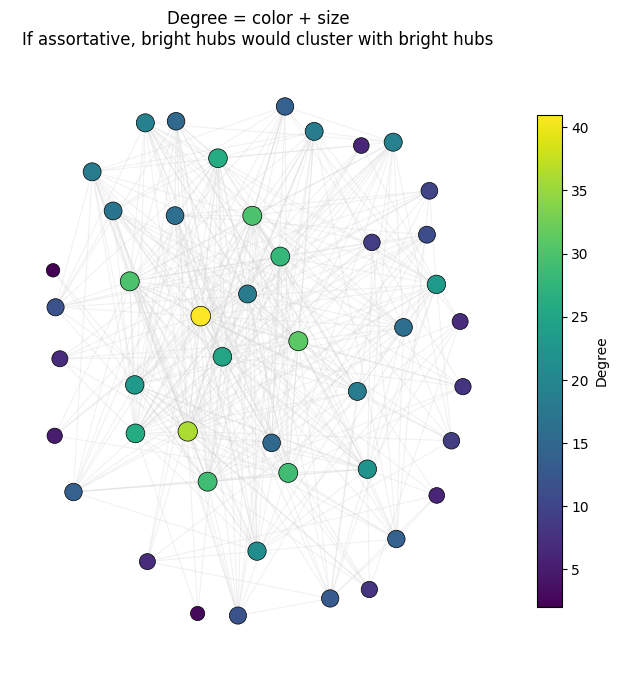

In [158]:

pos = nx.spring_layout(EliteNet, seed=42, k=2.6)

# Degree for color and size
degree_values = [degrees[n] for n in EliteNet.nodes()]
node_sizes = [50 + np.log1p(degrees[n]) * 40 for n in EliteNet.nodes()]

plt.figure(figsize=(8, 8))

# Nodes: color and size by degree
nodes = nx.draw_networkx_nodes(EliteNet, pos,
                                 node_color=degree_values,
                                 cmap='viridis',
                                 node_size=node_sizes,
                                 edgecolors='black',
                                 linewidths=0.5)

# All edges: neutral, faint
nx.draw_networkx_edges(EliteNet, pos,
                         edge_color='lightgray', alpha=0.3, width=0.8)

plt.colorbar(nodes, shrink=0.8, label='Degree')
plt.title("Degree = color + size\nIf assortative, bright hubs would cluster with bright hubs")
plt.axis('off')
plt.show()

We could use degree as a node attribute, as we did with the followers attribute:

In [159]:
pairs_excess = []
for u, v in EliteNet.edges():
    pairs_excess.append((degrees[u]-1, degrees[v]-1))  # see explanation below!
    pairs_excess.append((degrees[v]-1, degrees[u]-1))

df_sym_degrees_x = pd.DataFrame(pairs_excess, columns=['u_excess', 'v_excess'])
df_sym_degrees_x['u_excess'].corr(df_sym_degrees_x['v_excess'])

np.float64(-0.25411142369736284)

When computing degree assortativity, we subtract 1 because the edge you're standing on is already spent. The question is not "Do popular people have popular friends?" but "Given this friendship, do their remaining friendships cluster?" The `−1` accounts for the connection you've already used to get there.

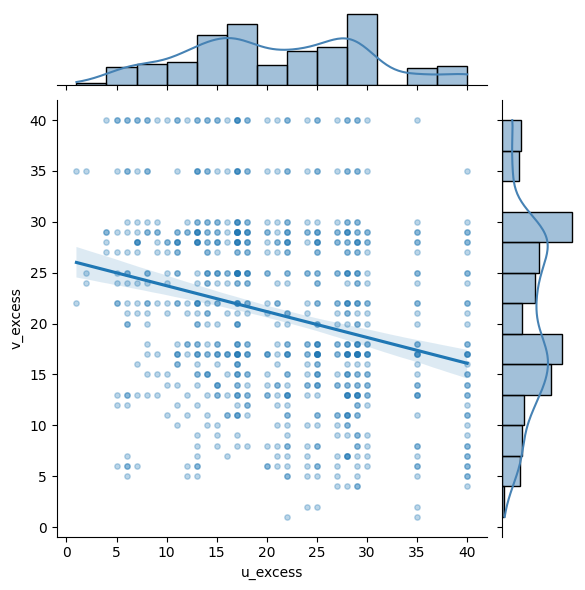

In [160]:
g = sns.jointplot(data=df_sym_degrees_x, x='u_excess', y='v_excess',
                  kind='reg',
                  joint_kws={'scatter_kws': {'alpha': 0.3, 's': 15}},
                  marginal_kws={'color': 'steelblue'})
plt.show()

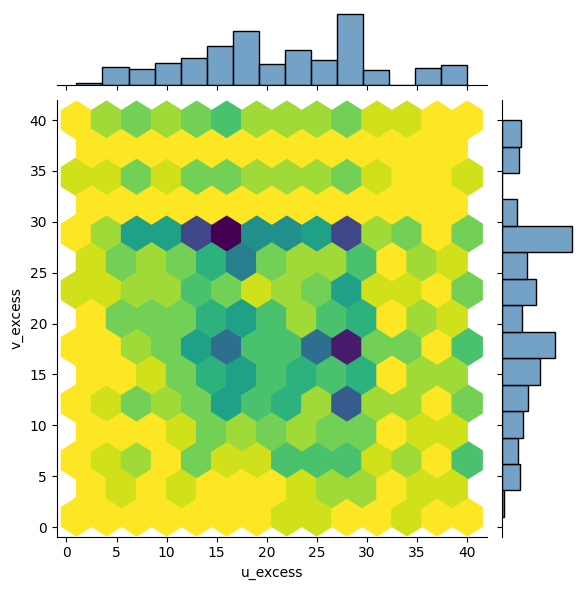

In [161]:
g = sns.jointplot(data=df_sym_degrees_x, x='u_excess', y='v_excess',
                  kind='hex', bins=15, cmap='viridis_r',
                  marginal_kws={'bins': 15, 'color': 'steelblue'})

plt.show()

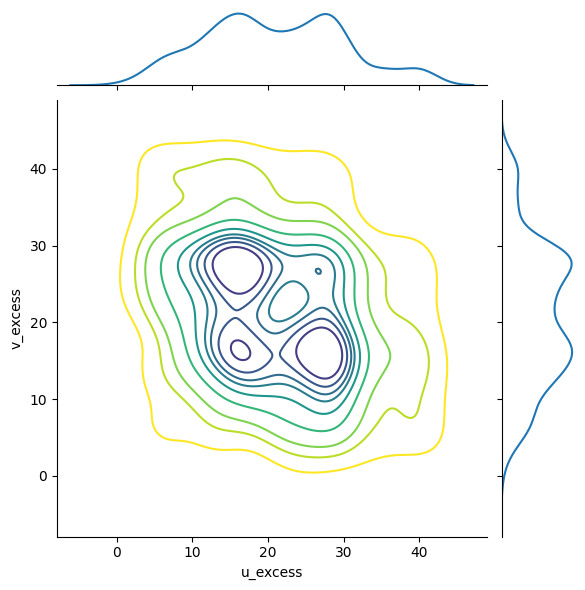

In [162]:
sns.jointplot(data=df_sym_degrees_x, x='u_excess', y='v_excess',
                  kind='kde',  cmap='viridis_r')


# Exploration of Network nodes

- The eigenvector of a vertex will tell you how well connected is a vertex; that is, vertices with the highest values are considered the most influential as they are connected to vertices that are also well connected.

- The closeness of a vertex will tell you how close is a vertex to every other vertex. A vertex with high closeness can share information faster than the rest.

- The betweeness of a vertex will tell you how critical is a vertex to connect vertex that are not connected directly.

In [163]:
# Computing centrality measures:

eigen=nx.eigenvector_centrality(EliteNet)

clos=nx.closeness_centrality(EliteNet)

betw=nx.betweenness_centrality(EliteNet)


In [164]:
# the dataframe of centralities

DFCentrality=pd.DataFrame(dict(Eigenvector = eigen,
                               Closeness = clos,
                               Betweenness = betw))


In [165]:
DFCentrality.reset_index(drop=False,names='person',inplace=True)
DFCentrality

,person,Eigenvector,Closeness,Betweenness
0,rachelerman,0.216208,0.750000,0.038210
1,mattmcilwain,0.129373,0.600000,0.004696
2,DaveParkerSEA,0.244652,0.833333,0.098119
3,toddbishop,0.267254,0.918367,0.111044
4,ashannstew,0.155090,0.625000,0.004576
5,LeslieFeinzaig,0.157292,0.625000,0.003989
6,akipman,0.042444,0.529412,0.000937
7,matt_oppy,0.199399,0.703125,0.025517
8,gilbert,0.149723,0.625000,0.005692
9,juliesandler,0.229808,0.762712,0.030922


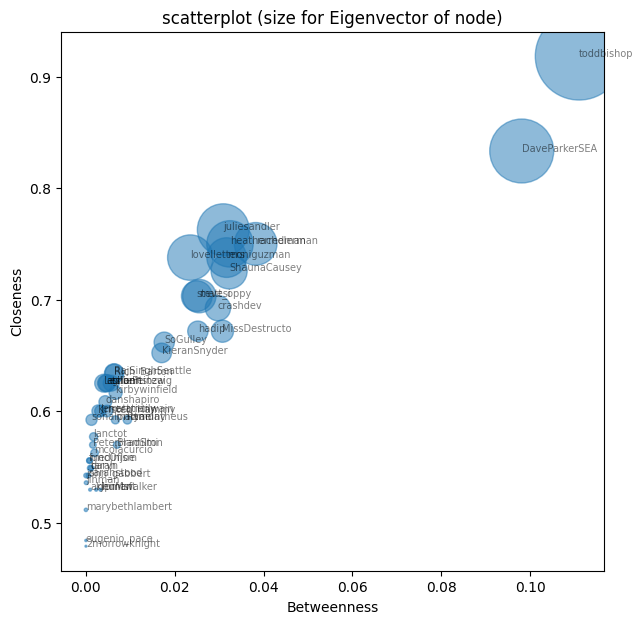

In [166]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(DFCentrality.Betweenness, DFCentrality.Closeness,s=(DFCentrality.Eigenvector+1)**35, alpha=0.5)

valsForAnnotate=zip(DFCentrality['person'],DFCentrality['Betweenness'],DFCentrality['Closeness'])

for name,coordX,coordY in valsForAnnotate:
    ax.annotate(name, (coordX,coordY),alpha=0.5,size=7)

plt.title("scatterplot (size for Eigenvector of node)")
plt.xlabel("Betweenness")
plt.ylabel("Closeness")
plt.show()

The previous results tells us that two people are salient:

In [167]:
# Determine the hub name:

labelsHubs={n:n for n in DFCentrality.nlargest(2, 'Eigenvector')['person']}
labelsHubs

{'toddbishop': 'toddbishop', 'DaveParkerSEA': 'DaveParkerSEA'}

let's highlight those guys:

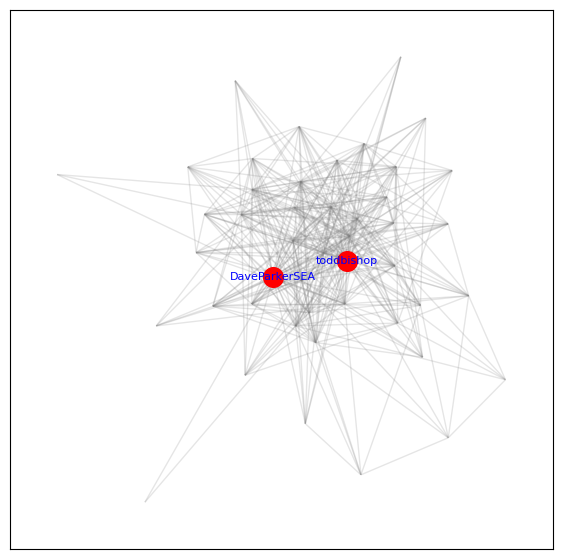

In [168]:
# prepare to plot:
fig, ax = plt.subplots(figsize=(7,7))

## positions of the nodes
pos=nx.spring_layout(EliteNet)

#edges
nx.draw_networkx_edges(EliteNet,pos,edge_color='grey',alpha=0.2)
# make the hub salient
nx.draw_networkx_nodes(EliteNet,pos,nodelist=labelsHubs,node_size=200,node_color='r')
# label the hubs
nx.draw_networkx_labels(EliteNet,pos,labels=labelsHubs,font_size=8,font_color='blue')

plt.show()

# Communities

Before hunting for communities, we first ask: does EliteNet have more triangles than chance would produce? If not, any "communities" we find might be algorithmic artifacts — patterns forced by the algorithm rather than real social structure.
Transitivity measures "friend of a friend is a friend" — the raw material for communities. We compare EliteNet to a random null model with the same number of nodes and edges. If the ratio is near 1, triangles are random noise. If it's significantly higher, communities are structurally possible

In [169]:
# EliteNet transitivity
elite_trans = nx.transitivity(EliteNet)
print(f"EliteNet transitivity: {elite_trans:.4f}")

# Random null model: same nodes, same edges, rewired
n = EliteNet.number_of_nodes()
m = EliteNet.number_of_edges()

random_transitivities = []
for _ in range(100):
    G_random = nx.gnm_random_graph(n, m)
    random_transitivities.append(nx.transitivity(G_random))

print(f"Random transitivity:   {np.mean(random_transitivities):.4f} ± {np.std(random_transitivities):.4f}")
print(f"Ratio Elite/Random:    {elite_trans / np.mean(random_transitivities):.2f}")

EliteNet transitivity: 0.5504
Random transitivity:   0.3784 ± 0.0084
Ratio Elite/Random:    1.45


EliteNet's transitivity is 45% higher than random — triangles are genuinely overrepresented. Communities have structural raw material; detection is worth pursuing.

A more complex algorithm is the [Louvain](https://perso.uclouvain.be/vincent.blondel/research/louvain.html):

In [184]:
partition_louvain=nx.community.louvain_communities(EliteNet,seed=123)

In [185]:
len(partition_louvain)

5

In [186]:

# Add community membership as node attribute
for i, community in enumerate(partition_louvain):
    for node in community:
        EliteNet.nodes[node]['community'] = i

# Verify
print(EliteNet.nodes(data=True))

[('rachelerman', {'male': 0, 'followers': 7139, 'community': 1}), ('mattmcilwain', {'male': 1, 'followers': 2804, 'community': 0}), ('DaveParkerSEA', {'male': 1, 'followers': 3328, 'community': 3}), ('toddbishop', {'male': 1, 'followers': 24500, 'community': 2}), ('ashannstew', {'male': 0, 'followers': 3382, 'community': 3}), ('LeslieFeinzaig', {'male': 0, 'followers': 15900, 'community': 4}), ('akipman', {'male': 1, 'followers': 29500, 'community': 2}), ('matt_oppy', {'male': 1, 'followers': 4847, 'community': 0}), ('gilbert', {'male': 1, 'followers': 25800, 'community': 0}), ('juliesandler', {'male': 0, 'followers': 7031, 'community': 0}), ('BradSmi', {'male': 1, 'followers': 96300, 'community': 2}), ('crashdev', {'male': 0, 'followers': 8773, 'community': 3}), ('ShaunaCausey', {'male': 0, 'followers': 47400, 'community': 1}), ('john_gabbert', {'male': 1, 'followers': 2482, 'community': 1}), ('moniguzman', {'male': 0, 'followers': 29000, 'community': 1}), ('mattmday', {'male': 1, 'fo

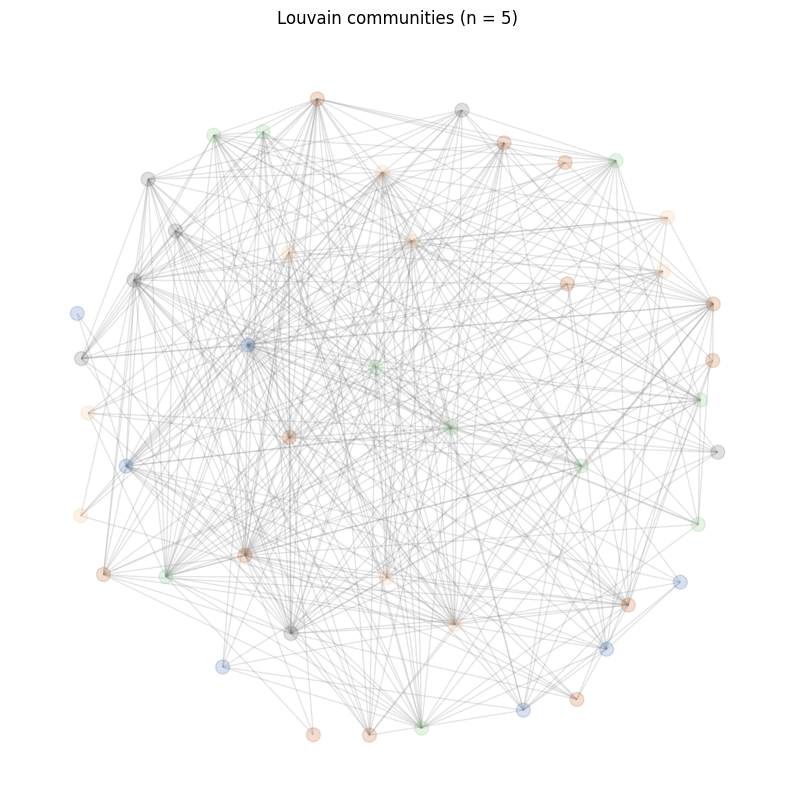

In [187]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spring_layout(EliteNet, seed=42, k=3)

# Extract community values for coloring
community_values = [EliteNet.nodes[n]['community'] for n in EliteNet.nodes()]

nx.draw(EliteNet, pos,
        node_color=community_values,
        cmap='Accent',
        node_size=100,
        edge_color='gray',
        alpha=0.2,
        ax=ax)

ax.set_title(f"Louvain communities (n = {len(partition_louvain)})")
ax.axis('off')
plt.show()

* Modularity `Q`:

If we get positive values (being 1 the top value), we could consider there are good community structures ([wiki](https://en.wikipedia.org/wiki/Modularity_(networks))). The higher modularity the connections between the nodes are dense  within a partition but sparse  between nodes in different partitions.

In [189]:
nx.community.modularity(EliteNet,partition_louvain)

0.10098802841067275

| Modularity `Q` | Interpretation                                 |
| ---------- | ---------------------------------------------- |
| < 0.3      | Weak/no meaningful communities                 |
| 0.3 – 0.7  | Moderate community structure                   |
| > 0.7      | Strong communities (possibly over-partitioned) |

> Louvain found communities, but modularity is only 0.10 — well below the 0.3 threshold. The communities are algorithmic output, not strong social structure. This aligns with what we found earlier: no gender assortativity, no follower assortativity, and only degree disassortativity. EliteNet lacks the homophily that typically drives real communities.

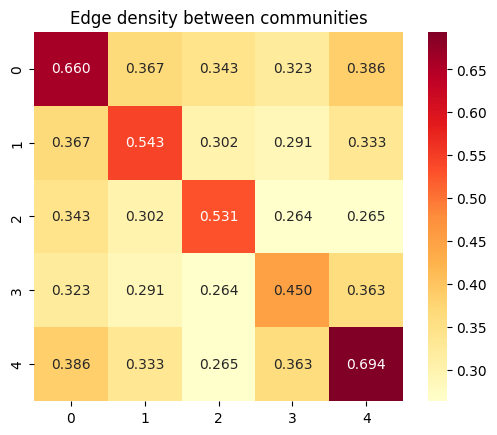

In [193]:
# Count edges between communities
partition = {n: EliteNet.nodes[n]['community'] for n in EliteNet.nodes()}

comm_edges = np.zeros((len(partition_louvain), len(partition_louvain)))
for u, v in EliteNet.edges():
    cu, cv = partition[u], partition[v]
    comm_edges[cu, cv] += 1
    comm_edges[cv, cu] += 1

# Normalize by community sizes
sizes = [len(c) for c in partition_louvain]
for i in range(len(sizes)):
    for j in range(len(sizes)):
        comm_edges[i, j] /= (sizes[i] * sizes[j])

sns.heatmap(comm_edges, annot=True, fmt='.3f', cmap='YlOrRd', square=True)
plt.title("Edge density between communities")
plt.show()

The diagonal is slightly denser — communities are not pure fiction. But the off-diagonal is far from empty.

Let me add the `ratio`: community-density divided by max density of other communities.

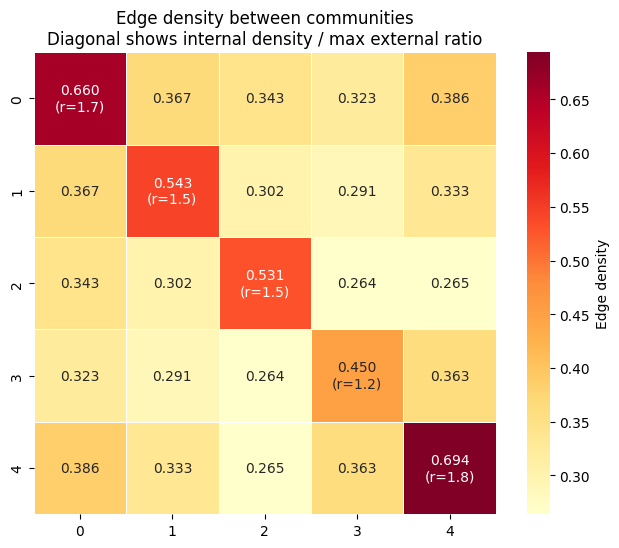

In [195]:
# Compute community edge density matrix
comm_edges = np.zeros((len(partition_louvain), len(partition_louvain)))
for u, v in EliteNet.edges():
    cu, cv = partition[u], partition[v]
    comm_edges[cu, cv] += 1
    comm_edges[cv, cu] += 1

# Normalize by community sizes
sizes = [len(c) for c in partition_louvain]
for i in range(len(sizes)):
    for j in range(len(sizes)):
        comm_edges[i, j] /= (sizes[i] * sizes[j])

# Compute ratios: diagonal / max off-diagonal for each community
ratios = []
for i in range(len(sizes)):
    diag = comm_edges[i, i]
    off_diag = [comm_edges[i, j] for j in range(len(sizes)) if j != i]
    max_external = max(off_diag)
    ratio = diag / max_external
    ratios.append(ratio)

# Annotate the heatmap with ratios
annot = np.empty_like(comm_edges, dtype=object)
for i in range(len(sizes)):
    for j in range(len(sizes)):
        if i == j:
            annot[i, j] = f"{comm_edges[i, j]:.3f}\n(r={ratios[i]:.1f})"
        else:
            annot[i, j] = f"{comm_edges[i, j]:.3f}"

plt.figure(figsize=(8, 6))
sns.heatmap(comm_edges, annot=annot, fmt="", cmap='YlOrRd', square=True,
            linewidths=0.5, cbar_kws={'label': 'Edge density'})

plt.title("Edge density between communities\nDiagonal shows internal density / max external ratio")
plt.show()

| Community | Internal | Max external | Ratio    |
| --------- | -------- | ------------ | -------- |
| 0         | 0.660    | 0.386        | **1.71** |
| 1         | 0.543    | 0.367        | **1.48** |
| 2         | 0.531    | 0.343        | **1.55** |
| 3         | 0.450    | 0.363        | **1.24** |
| 4         | 0.694    | 0.386        | **1.80** |

Community 4, the 'strongest,' has internal density 0.69 and max external density 0.39 — a ratio of only 1.8:1. Community 3 barely differs from its neighbors at 1.2:1. Real social communities typically show ratios of 5:1 or higher. At under 2:1, these are weak, leaky territorial boundaries

In [198]:
!pip install netgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.7/96.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.3/372.3 kB 15.3 MB/s eta 0:00:00


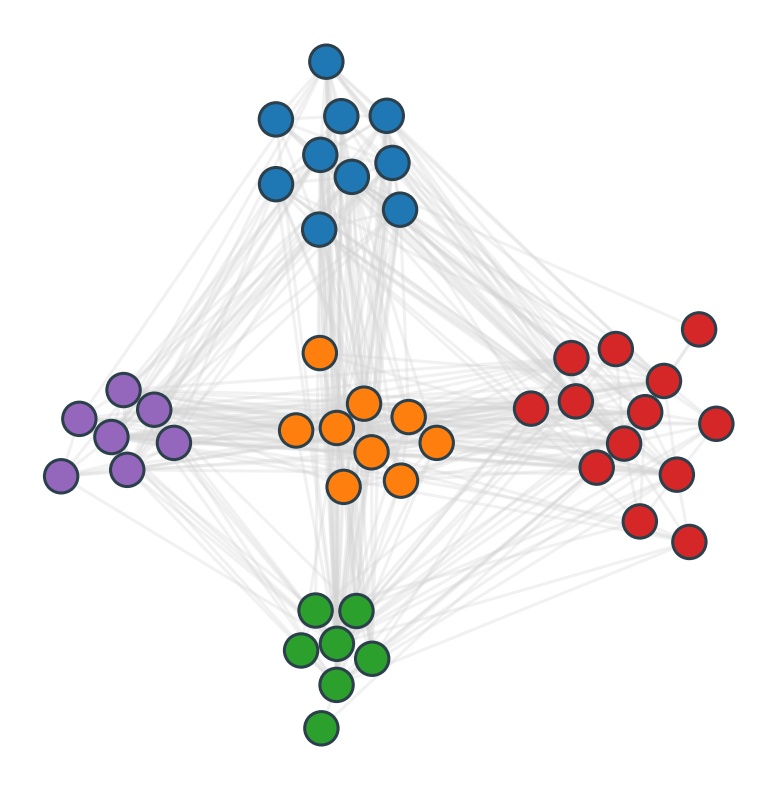

In [204]:
from netgraph import Graph


# Community mapping
node_to_community = {n: EliteNet.nodes[n]['community'] for n in EliteNet.nodes()}

# Custom colors
community_to_color = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green',
                      3: 'tab:red', 4: 'tab:purple'}
custom_node_color = {node: community_to_color[comm_id]
                     for node, comm_id in node_to_community.items()}

fig, ax = plt.subplots(figsize=(10, 10))

Graph(EliteNet,
      node_layout='community',
      node_layout_kwargs=dict(node_to_community=node_to_community),
      node_color=custom_node_color,
      edge_color='lightgrey',
      edge_alpha=0.3,
      edge_width=0.5,
      ax=ax)

plt.show()

`netgraph` produces this layout — five neat clusters. But this is algorithmic force, not social reality. The layout engine was told to group by community, so it groups by community. The math tells the real story: `Q = 0.10`, ratios under `2:1`. The clusters are weak and leaky. Visuals can always be forced to look clean; the math protects us from that illusion.